> **Purpose:** Real m=6000 benchmark (100 JC alignments, 6000 taxa x 5000 sites, with their
> true trees). Two questions, two figures: which split each operator reads off the full matrix
> and whether it is a real tree edge, then how much of that split survives sub-sampling.

# Similarity vs distance on the real 6000-taxa cohort

Two arms throughout, the same pair as `eta_by_operator.ipynb`:

| arm | operator | cut |
|---|---|---|
| `S` | $L(S) = \mathrm{Deg}(S) - S$, Fiedler vector | k-means ($k=2$) |
| `B` | $B = H\mathcal{D}H$, leading-$|\lambda|$ eigenvector | sign |

Data: `data/real_datasets/Datasets/6000 taxa/{fasta,newick}`.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedFormatter, FixedLocator

_R = Path.cwd()
while _R.parent != _R and not (_R / "setup.py").exists():
    _R = _R.parent
_root = _R / "sub_sampled_fielder_vec"
for _p in (str(_root), str(_R)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from analysis.utils.real6000 import FASTA_DIR, M_TAXA, SCREEN_IDS, SEQ_LEN
from analysis.utils.real_eta_screen import run_real_eta_screen
from analysis.utils.real_recovery_sweep import collect, sweep_meta

MIN_SPLIT, NUM_GAPS = 5, 10          # STDR/test convention used throughout the repo
P_VALUES = np.logspace(-4, 0, 20)    # sub-sampling rates, 1e-4 .. 1.0
REPS = 10                            # bootstrap reps per p
ARMS = [("S", r"$L(S)$, k-means"), ("B", r"$B=H\mathcal{D}H$, sign")]

CACHE_DIR = _root / "analysis" / "notebooks_cache" / "distance_vs_similarity_real"
SCREEN_CACHE = CACHE_DIR / "eta_screen_6000.npz"
SWEEP_DIR = CACHE_DIR / "sweep6000"

print(f"{len(SCREEN_IDS)} alignments, m={M_TAXA}, L={SEQ_LEN}")
print("fasta:", FASTA_DIR)

100 alignments, m=6000, L=5000
fasta: /Users/itayg/PythonRepo/spectral-tree-inference/sub_sampled_fielder_vec/data/real_datasets/Datasets/6000 taxa/fasta


## 1 - Which split each operator picks, and whether it is a real edge

Per tree: build $S$ and $\mathcal{D}$ once, read a bipartition off each operator, record its
imbalance $\eta$ = larger clan / smaller clan and whether it is a single-edge bipartition of the
true tree. ~75 s per tree at $m=6000$; cached, resumable, 4 workers.

In [3]:
rows = run_real_eta_screen(SCREEN_IDS, SCREEN_CACHE, workers=4)
df = pd.DataFrame([r for r in rows if "error" not in r])
print(f"\n{len(df)} trees screened, m={M_TAXA}")
df.groupby(["valid_S", "valid_B"]).size()

cache: 100 rows in eta_screen_6000.npz
nothing to do -- all ids cached

100 trees screened, m=6000


valid_S  valid_B
False    False       9
True     False      91
dtype: int64

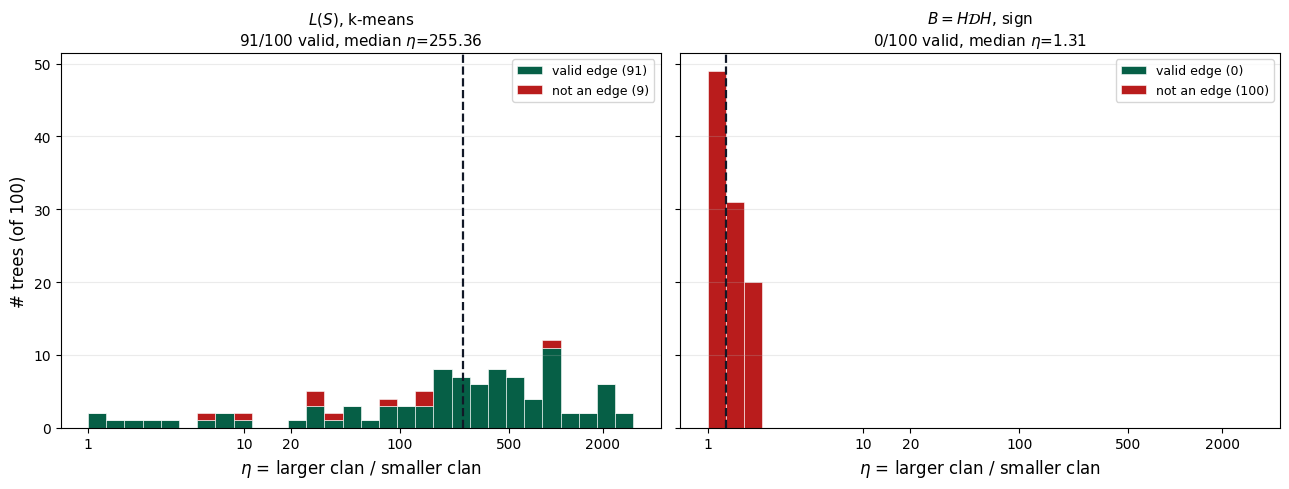

In [4]:
C_VALID, C_INVALID = "#065f46", "#b91c1c"      # green = real tree edge, red = not
XTICKS = [1, 10, 20, 100, 500, 2000]           # plain labels, not 10^k

hi = float(max(df["eta_S"].max(), df["eta_B"].max()))
bins = np.logspace(0, np.log10(hi * 1.05), 31)   # eta is a ratio spanning 1 .. ~m


def plain_log(axis, top=None):
    ticks = [t for t in XTICKS if t <= (top or hi) * 1.05]
    axis.set_major_locator(FixedLocator(ticks))
    axis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))
    axis.set_minor_locator(FixedLocator([]))


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (tag, aname) in zip(axes, ARMS):
    e, v = df[f"eta_{tag}"], df[f"valid_{tag}"]
    ax.hist([e[v], e[~v]], bins=bins, stacked=True,
            color=[C_VALID, C_INVALID], edgecolor="white", linewidth=0.4,
            label=[f"valid edge ({int(v.sum())})", f"not an edge ({int((~v).sum())})"])
    ax.axvline(float(e.median()), color="#111827", ls="--", lw=1.6)
    ax.set_xscale("log")
    plain_log(ax.xaxis)
    ax.set_title(f"{aname}\n{int(v.sum())}/{len(df)} valid, median $\\eta$={e.median():.2f}",
                 fontsize=11)
    ax.set_xlabel(r"$\eta$ = larger clan / smaller clan", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25, axis="y")
axes[0].set_ylabel(f"# trees (of {len(df)})", fontsize=12)
fig.tight_layout()
plt.show()

## 2 - Recovery under sub-sampling

Replace the full matrix by a uniform sub-sample at rate $p$, re-read the bipartition, score it by
NMI against that arm's own full-matrix reference. Cohort: the trees whose split is a real edge
under **both** operators.

The sweep is **not** run from here - the $L$ arm is ~30 min per tree at $m=6000$. Run it detached
and re-execute this cell:

```bash
cd sub_sampled_fielder_vec
nohup python scripts/run_real_sweep.py --cohort "6000 taxa" --stage sweep \
    > logs/real_sweep.log 2>&1 &
tail -f logs/real_sweep.log
```

In [5]:
META = sweep_meta(REPS, NUM_GAPS, MIN_SPLIT)
cohort = list(df.loc[df.valid_S & df.valid_B, "tree"])
nmi_L, nmi_B, have, pending = collect(cohort, SWEEP_DIR, P_VALUES, META)
print(f"cohort: {len(cohort)} both-valid trees - {len(have)} swept, {len(pending)} pending")
if pending:
    print("  pending e.g.", pending[:3], "-> scripts/run_real_sweep.py")

if have:
    P = np.round(P_VALUES, 6)
    fig, ax = plt.subplots(figsize=(7, 7))
    for data, name, col in [(nmi_B, r"$B=H\mathcal{D}H$, sign", "#065f46"),
                            (nmi_L, r"$L(S)$, k-means", "#4b5563")]:
        med = np.nanmedian(data, 0)
        sd = np.nanstd(data, 0)
        ax.plot(P, med, color=col, lw=2, marker="o", ms=3, label=name)
        ax.fill_between(P, med - sd, med + sd, color=col, alpha=0.15)
    ax.set_xscale("log")
    ax.set_xlabel(r"sub-sampling fraction $p$ (log)", fontsize=12)
    ax.set_ylabel("NMI vs full-matrix reference", fontsize=12)
    ax.set_xlim(P.min() * 0.8, 1.2)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=11, loc="lower right")
    fig.suptitle(f"Sub-sampling recovery at $m={M_TAXA}$: median NMI over {len(have)} trees "
                 f"(band = $\\pm$1 std), {REPS} reps per $p$", fontsize=12)
    fig.tight_layout()
    plt.show()

cohort: 0 both-valid trees - 0 swept, 0 pending
